# DSA8002 Coursework Assignment

## Preliminaries

In [1]:
# Imports and modules
import pandas as pd

In [2]:
# Loading the data
movies_df = pd.read_csv('movies_data/tmdb_5000_movies.csv')
credits_df = pd.read_csv('movies_data/tmdb_5000_credits.csv')

In [3]:
# Checking the data frames are loaded correctly:
movies_df.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


In [4]:
credits_df.head()

,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de..."
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de..."


Now, I will begin cleaning the data set, first by removing unreleased movies from the `movies_df` data frame.

In [5]:
movies_released = movies_df[movies_df['status'] == 'Released']

# Checking to see how many rows are in the movies_released data frame
print(movies_released.shape)
# Checking to see how many rows are in the movies_df data frame
print(movies_df.shape)

(4795, 20)
(4803, 20)


We can see that 8 rows were removed, implying there were 8 movies which were unreleased in the data set.

Next, I will remove columns with more than 100 NaN values.

In [6]:
# Checking to see which columns have NaN values and how many there are.
movies_nan_count = movies_released.isna().sum()
print(movies_nan_count)

budget                     0
genres                     0
homepage                3086
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  838
title                      0
vote_average               0
vote_count                 0
dtype: int64


We can see NaNs are present in the following columns: `homepage, overview, release_date, runtime and tagline`. The `homepage` and `tagline` columns have more than 100 NaNs, as such these will be the columns that I'll remove.

In [7]:
# Using movies_nan_count to create a mask where the values are less than 100
movies_nan_free_mask= movies_nan_count <= 100

# Using the mask defined above to filter the movies_released data frame
movies_nan_free = movies_released.loc[:, movies_nan_free_mask]

# Checking the data frame
movies_nan_free.head()

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,John Carter,6.1,2124


As we expected, the columns: `homepage` and `tagline` have been removed.

Next, I will remove the `status` column, as the `homepage` and `tagline` columns have already been removed.

In [8]:
# Using the drop method in pandas, where I specified status as the column to be dropped using 'status', axis = 1
movies_columns_cleaned = movies_nan_free.drop('status', axis = 1)

movies_columns_cleaned.head()

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",John Carter,6.1,2124


As we can see above, the `status` column has been dropped.

Next, I will drop any duplicate rows using the `drop_duplicates` method in pandas

In [9]:
# Using the drop_duplicates method across all columns 
movies_no_duplicates = movies_columns_cleaned.drop_duplicates()
# Checking the shapes of the data frames
print(movies_columns_cleaned.shape, movies_no_duplicates.shape)

(4795, 17) (4795, 17)


We can see that the number of rows remained the same, as such there were no duplicate rows to remove

The final step in this data cleaning process will be removing any remaining rows which have NaN values, to do this I will use the pandas method `dropna()`

In [10]:
# Kept encountering an error (SettingWithCopyWarning) when I was using this dataframe to perform SQL queries on
# in task 1. I would receive the expected table after each SQL query, just an error message would appear.
# After plenty of research I wasn't able to figure out what as causing this, I asked ChatGPT which
# suggested that pandas is unsure if the dataframe movies_cleaned is a view (i.e. a slice of the movies_no_duplicates dataframe)
# or if it was a copy. As such I used the .copy() method and this seemed to resolve the issue.

# Using the pandas dropna() method to drop rows which have NaN values
movies_cleaned = movies_no_duplicates.dropna().copy()
# Checking the shape of the movies_no_duplicates data frame compared to the movies_cleaned data frame
print(movies_no_duplicates.shape, movies_cleaned.shape)


(4795, 17) (4791, 17)


As we can see, 4 rows contained NaN values and subsequently were dropped.

## Task 1 

In [11]:
# First we need to import the PandaSQL module
import pandasql as ps

# To keep in mind the current state of the dataframe
movies_cleaned.head()

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",John Carter,6.1,2124


### 1. Determining how many movies were released in a language other than English

In [12]:
# Getting a count of all rows where the original_language column is not equal to "en"
sql_command = '''
SELECT COUNT(original_language) as 'Number of movies'
FROM movies_cleaned
WHERE original_language <> "en"
'''

count_non_en = ps.sqldf(sql_command)
count_non_en

,Number of movies
0,295


Looking at the table above, we see that there were `295` movies that were first released in a language other than English.

## 2. Creating a table called movie_countries, with 4 columns: the title of the movie and the first three countries listed in production_countries

In [13]:
# Using JSON_EXTRACT to convert the character string in each row of of the production_countries column to JSON.
# The $[i] indicates the index and the . indicates which key.
# Here we are interested in the indexes 0,1,2 and the key 'name'
sql_command = '''
SELECT original_title, 
JSON_EXTRACT(movies_cleaned.production_countries, "$[0].name") AS Country_1, 
JSON_EXTRACT(movies_cleaned.production_countries, "$[1].name") AS Country_2, 
JSON_EXTRACT(movies_cleaned.production_countries, "$[2].name") AS Country_3
FROM movies_cleaned
'''

movie_countries = ps.sqldf(sql_command)

# Checking the table has been created as expected
movie_countries.head()

,original_title,Country_1,Country_2,Country_3
0,Avatar,United States of America,United Kingdom,None
1,Pirates of the Caribbean: At World's End,United States of America,None,None
2,Spectre,United Kingdom,United States of America,None
3,The Dark Knight Rises,United States of America,None,None
4,John Carter,United States of America,None,None


## 3. Using movie_countries to determine how many movies are co-produced between exactly 2 countries

In [14]:
# The website https://www.w3schools.com/sql/sql_null_values.asp
# helped me understand how to deal with NULL values which appear as None in the table above

# Looking at the table above, I noticed some rows don't have a string for any country column. 
# I took this into consideration and made sure to only count rows where Country_1 is not NULL and 
# Country_2 is not NULL and Country_3 is NULL
sql_command = '''
SELECT COUNT(*)
FROM movie_countries
WHERE Country_3 IS NULL AND Country_2 IS NOT NULL AND Country_1 IS NOT NULL
'''

count_produced_by_2 = ps.sqldf(sql_command)
count_produced_by_2

,COUNT(*)
0,851


Looking at the table produced above, we see that the number of movies which are co-produced between exactly 2 countries is `851`.

## 4. Creating a table with the following columns: names of the countries in movie_countries as columns, the number of times they appear as a primary production country and the number of times they appear as a secondary production company

In [15]:
# Grouping by each country and then using COUNT to sum how many times
# each country appears as a primary and secondary producer, using these to create the respective columns
# not including NULL values
# then sorting each row by the Primary_Production_Count column, largest first.
sql_command = '''
SELECT 
JSON_EXTRACT(movies_cleaned.production_countries, "$[0].name") AS Country_Names, 
COUNT(JSON_EXTRACT(movies_cleaned.production_countries, "$[0].name")) AS Primary_Production_Count,
COUNT(JSON_EXTRACT(movies_cleaned.production_countries, "$[1].name")) AS Secondary_Production_Count
FROM movies_cleaned
WHERE Country_Names IS NOT NULL
GROUP BY Country_Names
ORDER BY Primary_Production_Count DESC

'''

country_counts = ps.sqldf(sql_command)
country_counts.head()

,Country_Names,Primary_Production_Count,Secondary_Production_Count
0,United States of America,3098,125
1,United Kingdom,372,243
2,Canada,220,174
3,Germany,200,185
4,France,174,125


Looking at the table above (country_counts), we see that the `United States of America` appears as the primary production company the most, with a count of `3098`.

## Calculating the total number of times each country is listed as the first or second production company. Then printing the top 5 countries in the order of how many films they produce

In [16]:
# Grouping by each country and then using COUNT to sum how many times
# each country appears as a primary and secondary producer, then adding these values together for each row
# not including NULL values
# Then ordering by highest first and limiting the table to the first 5 rows produced.
sql_command = '''
SELECT 
JSON_EXTRACT(movies_cleaned.production_countries, "$[0].name") AS Country_Names, 
COUNT(JSON_EXTRACT(movies_cleaned.production_countries, "$[0].name")) + COUNT(JSON_EXTRACT(movies_cleaned.production_countries, "$[1].name")) AS Primary_Secondary_Production_Count
FROM movies_cleaned
WHERE Country_Names IS NOT NULL
GROUP BY Country_Names
ORDER BY Primary_Secondary_Production_Count  DESC
LIMIT 5

'''

top_5_countries = ps.sqldf(sql_command)
top_5_countries

,Country_Names,Primary_Secondary_Production_Count
0,United States of America,3223
1,United Kingdom,615
2,Canada,394
3,Germany,385
4,France,299


## Task 2

In [17]:
# In order to proceed with task 2, 
# I will first create a dataframe with only rows with a budget column greater than 100,000 and 
# a revenue column greater than 0.
movies_budget_mask = (movies_cleaned['budget'] > 100000) & (movies_cleaned['revenue'] > 0)

# Encountered SettingWithCopyWarning again when I was using this dataframe to create plots
# later in this task. The plots were correct and everything worked fine, just an error message would appear
# like before.
# Using advice obtained from ChatGPT earlier in this project, I determined
# that pandas is unsure if the dataframe movies_task2 is a view 
# (ie a slice of the movies_cleaned dataframe)
# or if it was a copy. As such I used the .copy() method and this seemed to resolve the issue.
movies_task2 = movies_cleaned[movies_budget_mask].copy()
movies_task2.head()

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",John Carter,6.1,2124


### 1. Calculating and printing the percentage of movies that make a loss

In [18]:
# Total number of films in filtered dataframe
total_films = len(movies_task2)

# Creating a mask which contains booleans indicating whether budget is greater
# than revenue for each row
loss_mask = movies_task2['revenue'] < movies_task2['budget']

# Total number of rows (films) where the revenue is less than the budget
total_films_loss = len(movies_task2[loss_mask])

# Calculating the percentage of movies that make a loss
percentage_loss = (total_films_loss/total_films)*100

# Wasn't sure how to print a % sign in a string, found this article:
# https://stackoverflow.com/questions/5306756/how-to-print-a-percentage-value#:~:text=0f%20stands%20for%20%22print%20a,than%20your%20original%20%2B'%25'
print('The percentage of movies that make a loss in the movies_task2 dataframe is %.2f%%' %percentage_loss)

The percentage of movies that make a loss in the movies_task2 dataframe is 24.46%


### 2. Calculating and printing the median of the ratio of Revenue to Budget

In [19]:
# Calculating the ratios using the divide method in pandas to avoid NaNs
movies_task2['revenue_budget_ratio'] = movies_task2['revenue'].divide(movies_task2['budget'])

In [20]:
# Calculating the median of the revenue_budget_ratio column
median_ratio = movies_task2['revenue_budget_ratio'].median()
print('The median of the ratio of Revenue to Budget is %.2f' %median_ratio)

The median of the ratio of Revenue to Budget is 2.29


### 3. Making a scatter plot of revenue vs budget


In [21]:
# First importing matplotlib.pyplot
import matplotlib.pyplot as plt
import numpy as np

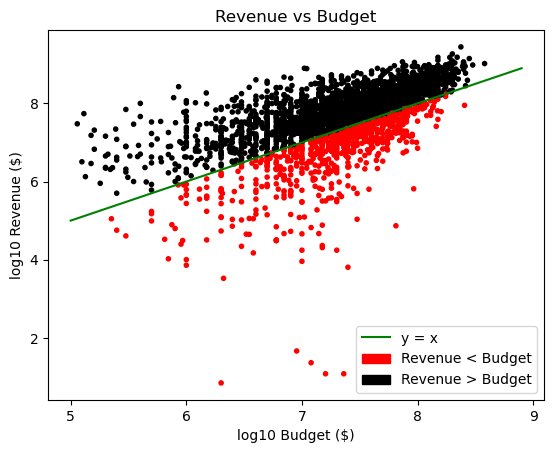

In [22]:
fig, ax = plt.subplots()

# Performing a log10 transformation on the budget column and the revenue column
movies_task2['log_budget'] = np.log10((movies_task2['budget']))
movies_task2['log_revenue'] = np.log10((movies_task2['revenue']))


# Using https://stackoverflow.com/questions/40803570/specify-color-points-depending-on-conditions
# I set the colour of the point to be either black or red depending on if the movie made a loss
# Condition is if the observation on the log_revenue column is less than the observation
# on the log_budget column for each row
col = np.where(movies_task2['log_revenue']<movies_task2['log_budget'],'r','k')
ax.scatter(movies_task2['log_budget'], movies_task2['log_revenue'], c = col, marker='.')


ax.set_xlabel('log10 Budget ($)')
ax.set_ylabel('log10 Revenue ($)')

# Setting the ticks for the x and y axis
ax.set_xticks([5,6,7,8,9])
ax.set_yticks([0,2,4,6,8,10])



# To manually create a legend, I closely followed:
# https://stackoverflow.com/questions/39500265/how-to-manually-create-a-legend
# mixing gabra's and CreekGeek's solutions
import matplotlib.patches as mpatches

red_patch = mpatches.Patch(color='r', label='Revenue < Budget')
blue_patch = mpatches.Patch(color='k', label='Revenue > Budget')

# Straight line y = x, to help visualise the break even point
x_arr = np.arange(5,9,0.1)

y_straight = x_arr

plt.plot(y_straight, x_arr, color ='g', label = 'y = x' )

# Accessing legend objects automatically created from data
handles, labels = plt.gca().get_legend_handles_labels()

# Adding manual symbols to auto legend
handles.extend([red_patch, blue_patch])

plt.legend(handles=handles, loc = 'lower right', frameon=True)

ax.set_title('Revenue vs Budget')

plt.show()

I added a green line $ y = x $ to help with the visualisation of where revenue becomes greater than the budget, as $ y = x $ is the break even point where `Revenue = Budget`, that is, `Revenue - Budget = 0`. We can see that the points below y = x are red (no profit) and the points above the line are black (profit made).

### 4. Determining whether there is a positive or negative correlation between revenue and budget, using Spearman's Rank Correlation Coefficient

In [23]:
# Importing the spearmanr function from scipy.stats:

from scipy.stats import spearmanr

# Calculating and printing the Spearman coefficient and it's significance
print(spearmanr(movies_task2['log_revenue'],movies_task2['log_budget']))

SignificanceResult(statistic=0.6742076461874965, pvalue=0.0)


Here we have a Spearman Coefficient greater than 0, suggesting a positive correlation. The Spearman coefficient valye of `0.674` suggests that this `positive correlation` is moderate-strong in strength. 
The p-value returned is the significance, which is less than 0.05 and 0.001, and so we can say the positive correlation is `highly statistically significant`, that is there is a very low probability that the observed correlation is due to chance.

### 5. Fitting a mathematical relationship to the data on the budget vs revenue.

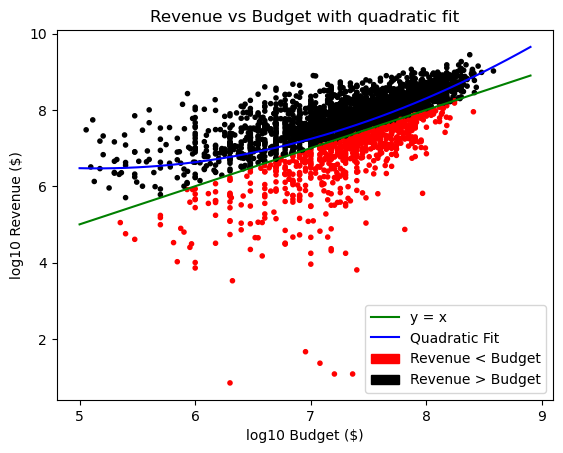

In [24]:
fig, ax = plt.subplots()

# Performing a log10 transformation on the budget column and the revenue column
movies_task2['log_budget'] = np.log10((movies_task2['budget']))
movies_task2['log_revenue'] = np.log10((movies_task2['revenue']))


# Using https://stackoverflow.com/questions/40803570/specify-color-points-depending-on-conditions
# I set the colour of the point to be either black or red depending on if the movie made a loss
# Condition is if the observation on the log_revenue column is less than the observation
# on the log_budget column for each row
col = np.where(movies_task2['log_revenue']<movies_task2['log_budget'],'r','k')
ax.scatter(movies_task2['log_budget'], movies_task2['log_revenue'], c = col, marker='.')


ax.set_xlabel('log10 Budget ($)')
ax.set_ylabel('log10 Revenue ($)')

# Setting the ticks for the x and y axis
ax.set_xticks([5, 6, 7, 8, 9])
ax.set_yticks([0,2,4,6,8,10])

ax.set_title('Revenue vs Budget with quadratic fit')

# Fitting a second degree fit of the data using np.polyfit
f = np.polyfit(x=movies_task2['log_budget'], y=movies_task2['log_revenue'], deg=2)

x_arr = np.arange(5,9,0.1)

# The second degree fit gives us three coefficients, rather than two, and the first is the coefficient of x^2:
y_mod2 =  f[0] * x_arr**2 + f[1]*x_arr + f[2]

y_straight = x_arr


# To manually create a legend, I closely followed:
# https://stackoverflow.com/questions/39500265/how-to-manually-create-a-legend
# mixing gabra's and CreekGeek's solutions

red_patch = mpatches.Patch(color='r', label='Revenue < Budget')
blue_patch = mpatches.Patch(color='k', label='Revenue > Budget')

# y = x to help visualise break even point
plt.plot(y_straight, x_arr, color ='g', label = 'y = x' )

# Quadratic fit
plt.plot(x_arr, y_mod2, color='b', label = 'Quadratic Fit')

# Accessing legend objects automatically created from data
handles, labels = plt.gca().get_legend_handles_labels()

# Adding manual symbols to auto legend
handles.extend([red_patch, blue_patch])

plt.legend(handles=handles, loc = 'lower right', frameon=True)




plt.show()

This is the same plot as before except with the quadratic fit curve plotted as well. We can see by looking at the curve that the minimum is around $ x = 5 $ after which, as the $log_{10}$Budget increases $log_{10}$Revenue increases.

#### The blue line is the fitted quadratic model.

In [25]:
print('So for y = m*x^2 + n*x + c')

# So for y = m*x^2 + n*x + c, this is m:
print('m = %.3f' %f[0])

# This is n
print('n = %.3f' %f[1])

# And this is the constant c:
print('c = %.3f' %f[2])


So for y = m*x^2 + n*x + c
m = 0.227
n = -2.334
c = 12.480


Therefore the mathematical relation to the data on budget vs revenue is:
$$ y = 0.227x^2 - 2.334x + 12.480 $$

In [26]:
# Using the relation, the predicted revenue for a movie with a budget of 10,000,000 is:

# Since the relation is in log10 we need to transform the budget with log10
budget = np.log10(10000000)
# This returns y in log10 form
log_predicted_y = f[0]*budget**2 + f[1]*budget + f[2]

# Reversing the log10 transformation
predicted_y = 10**log_predicted_y


print('The predicted revenue for a movie with a budget of $10,000,000 using the mathematical relation is: $%.2f\n' %predicted_y)
budget = 10000000
# Calculating the predicted revenue using the median ratio and a budget of $10,000,000
median_prediction = budget*median_ratio

print('The predicted revenue for a movie with a budget of $10,000,000 using the median of the ratio of Revenue to Budget is: $%.2f' %median_prediction)


The predicted revenue for a movie with a budget of $10,000,000 using the mathematical relation is: $17422835.39

The predicted revenue for a movie with a budget of $10,000,000 using the median of the ratio of Revenue to Budget is: $22931177.17


As we see above, the prediction obtained using the mathematical relation (17,422,835.39 Dollars) is `not consistent` with what you'd expect using the median of the ratio of Revenue to Budget (22,931,177.17 Dollars).

### 6. On whether there is a minimum investment above which a movie is very likely to be profitable

We can look at the plot in question 3 and see that the minimum of the quadratic is between x = 5 and x = 5.5, after which any increase in `log Budget` leads to a bigger increase in `log Revenue`.

In order to quantify this we can use differentiation by finding the exact x value at which the minimum occurs.

Looking at: 

$$y = 0.227x^2 -2.334x + 12.480$$


Using first order differentiation and setting $dy/dx = 0$, we get:


$$ 0.454x - 2.334 = 0 $$

Which implies:

$$ x = 5.141 $$

We can perform a second order differentiation to check if this is a minimum or maximum which gives:

$$ 0.454 > 0 $$
Implying it is indeed a minimum.

In order to convert this to the `Budget` in Dollars, we need to reverse the log10 transformation.

We will denote this critical budget as $B_{crit}$. Therefore:

$$ B_{crit} =  10^{5.141} = $138,356.64 $$

That is, any minimum investment above `$138,356.64` is likely to be profitable according to the quadratic model.



## Task 3 - Designing a recommendation system to help users find movies that are similar to other movies that they like

First, I will merge the 2 dataframes using the id column in the `movies_cleaned` dataframe and the movie_id column in the `credits_df` dataframe, as these are unique identifies for each movie.

In [27]:
# Merging the 2 dataframes using pandas merge function.
merged_df = pd.merge(movies_cleaned, credits_df, left_on = 'id', right_on='movie_id')

# Check initial dtype of release_date column:
print('Before: ', merged_df['release_date'].dtypes)

# Convert release_date column to datetime dtype:
merged_df['release_date'] = pd.to_datetime(merged_df['release_date'])


# Check new dtype:
print('After: ', merged_df['release_date'].dtypes)



Before:  object
After:  datetime64[ns]


We can see that the `release_date` column's type has been change to a datetime type, time to continue with extracting just the year from each row in the `release_date` column to create a new column.

In [28]:
# Using the pandas function we extract the year each row in the
# 'release_date' column, then use that year to create rows for the new
# column 'release_year'
merged_df['release_year'] = merged_df['release_date'].dt.year
merged_df.head()

,budget,genres,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,...,runtime,spoken_languages,title_x,vote_average,vote_count,movie_id,title_y,cast,crew,release_year
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Avatar,7.2,11800,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",2009
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Pirates of the Caribbean: At World's End,6.9,4500,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",2007
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Spectre,6.3,4466,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",2015
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",The Dark Knight Rises,7.6,9106,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",2012
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",John Carter,6.1,2124,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",2012


Moving on to building the function:

In [29]:
# In order to understand how to pass a function argument through an SQL query, I followed:
# https://stackoverflow.com/questions/63603433/how-to-pass-in-parameters-to-a-sql-statement-in-python

In [30]:
import json

# Creating a function called formatter which takes a dataframe 
# and returns an output containing the movie's title, overview, vote_average,
# runtime, release_year and who the main actor stars as
def formatter(df):
    print('Getting movie suggestions...\n')
    for i in range(len(df)):
        # Going through each row (movie) in the dataframe and defining variables to be used in the print statement
        movie_title = df.loc[i, 'original_title']
        overview = df.loc[i, 'overview']
        vote_average = df.loc[i, 'vote_average']
        runtime = df.loc[i, 'runtime']
        release_year = df.loc[i, 'release_year']
        starring = df.loc[i, 'Starring']
        character = df.loc[i, 'Character']
        
        print('\n%d. %s (%s)\n\nStarring: %s as %s\n\nOverview:\n%s\n\nAverage vote: %.1f/10\nRuntime: %d minutes\n' %(i+1,movie_title, release_year, starring, 
                                                                                                             character,overview, vote_average, runtime))
        



def get_matching_movies(movie = ""):
    
    try:
        
    
    # Selecting the first value from the name key in the JSON string in the cast column
    # then selecting the first and second values from the name key in the genres column
    # where the row in the original_title column is equal to the argument movie.
        sql_command = '''
            SELECT JSON_EXTRACT(merged_df.cast, "$[0].name") AS main_actor,
                JSON_EXTRACT(merged_df.genres, "$[0].name") AS genre_1,
                JSON_EXTRACT(merged_df.genres, "$[1].name") AS genre_2,
                release_year
            FROM merged_df
            WHERE original_title = '%s' ''' %(movie)


        # Creating a table which has one row and 3 columns which contain the information I want 
        # to search the merged_df by
        search_criteria = ps.sqldf(sql_command)


        # If no input is detected then:
        # We select the columns we want
        # from the merged_df dataframe
        # then we sort these by popularity, with highest first
        # then limit the size of the dataframe to 5 rows

        if movie == '':
            sql_command = '''
                SELECT popularity, original_title, 
                    vote_average, overview, runtime, release_year,
                    JSON_EXTRACT(merged_df.cast, "$[0].name") as 'Starring',
                    JSON_EXTRACT(merged_df.cast, "$[0].character") as 'Character'
                FROM merged_df
                ORDER BY popularity DESC
                LIMIT 5
            '''

            overallmostpop = ps.sqldf(sql_command)
            print('No movie inputted...\nReturning the top 5 most popular movies instead...')

            return formatter(overallmostpop)

        # If the length of the search_criteria dataframe is 0, this implies
        # no rows were found with the criteria, as such, a warning message is outputted
        elif len(search_criteria) == 0:
            return print('Warning!\nNo movie found with the title: "%s". Please try again!' %movie)
        # If this is not the case carry on with the SQL query below
        else:

        # Selecting the columns we are interested in from merged_df dataframe:
        # We want a column for the main actor of the movie and a column for their starring role
        # To do this we need to access the cast column which has JSON strings. 
        # Using JSON_EXTRACT, we can extract the keys and their respective values that we want

        # Next, using the search_criteria dataframe, we only select rows from merged_df
        # where the genres are matching that in the search_criteria dataframe
        # and where the release_year in each row of merged_df is within 5 years of the search_criterias release_year
        # The final condition is where the row isn't equal to the movie that was inputted, to avoid
        # repetition.
            sql_command = '''
                SELECT popularity, original_title, 
                    vote_average, overview, runtime, release_year,
                    JSON_EXTRACT(merged_df.cast, "$[0].name") as 'Starring',
                    JSON_EXTRACT(merged_df.cast, "$[0].character") as 'Character'
                FROM merged_df
                WHERE 
                    JSON_EXTRACT(merged_df.genres, "$[0].name") = (
                    SELECT genre_1
                    FROM search_criteria
                    ) 
                    AND
                    JSON_EXTRACT(merged_df.genres, "$[1].name") = (
                    SELECT genre_2
                    FROM search_criteria
                    ) 
                    AND
                    release_year <= (
                    SELECT release_year+5
                    FROM search_criteria)
                    AND
                    release_year >= (
                    SELECT release_year-5
                    FROM search_criteria)
                    AND
                    original_title <> '%s'
                ORDER BY popularity DESC
                LIMIT 5

            ''' %movie
            result = ps.sqldf(sql_command)
            return formatter(result)

    except Exception:
        return("An unexpected error has occured, please try a different input.")




For my movie recommendation system I decided to look at the `genre` and the `release_year` for the movie inputted. Specifically for `genre`, I accessed the first 2 genres in each JSON string in the `genre` column. The idea is to use not just use the first genre listed for each movie but the first 2 listed, so that I can use these 2 genres to search for movies with matching genres, providing recommendations which are more similar to the movie inputted than if 1 genre was used. I tried 3 genres but found that the results were inconsistent and sometimes no movies were returned, as such I found 2 genres to be the perfect balance containing a high degree specificity but also a high volume of results returned.

Next onto the release year, I wanted the system to recommend movies of a similar period, I found that using the exact release year as my search criteria provided limiting results. As such, I decided to use the `release_year` plus 5 years and the `release_year` minus 5 years. This provides a wider range of results returned when used in conjunction with the 2 genres.

In order to make my SQL queries easier to read, I decided to use pandas to first merge the 2 dataframes, then proceeded to use SQL to query the merged dataframe using the 2 aforementioned conditions as my search criteria., returning 5 results in order of popularity (highest first). The results returned strike a balance and provide good recommendations. 

In order to deal with errors, I implemented a general try, except error handler to deal with any unexpected errors. As for if nothing was called that is the function was used just as `get_matching_movies()` with no argument, I implemented the default movie argument to be `''`. Bringing us onto if `''` is passed through the function. Then, the top 5 movies by popularity of all time are returned and the user is made aware of this.

If the movie isn't in the dataframe an error is returned and the user is suggested to try search for another movie. I considered if just an integer is entered e.g. `get_matching_movies(5)`, but this is converted to a string during the SQL queries and most, if not all characters can be succesfully converted to strings as such, I did not find a need to implement a TypeError.

I also wanted the output to be user friendly, as such I created a function called `formatter` which takes the returned dataframe from the SQL query and provides the `title` and the `year released`, then a line containing the `main actor` and who they `star` as. Then an `overview`, followed by the `average vote` of the movie and the `runtime`.

Below you can see some examples testing the error handling of the function and the user friendly formatting.

#### Testing the get_matching_movies function

In [31]:
# Testing the output of the get_matching_movies with an input not in the dataframe
get_matching_movies('DSA8002 the Movie')

Warning!
No movie found with the title: "DSA8002 the Movie". Please try again!


In [32]:
# Testing the output of the get_matching_movies with an empty input
get_matching_movies('')

No movie inputted...
Returning the top 5 most popular movies instead...
Getting movie suggestions...


1. Minions (2015)

Starring: Sandra Bullock as Scarlet Overkill (voice)

Overview:
Minions Stuart, Kevin and Bob are recruited by Scarlet Overkill, a super-villain who, alongside her inventor husband Herb, hatches a plot to take over the world.

Average vote: 6.4/10
Runtime: 91 minutes


2. Interstellar (2014)

Starring: Matthew McConaughey as Joseph Cooper

Overview:
Interstellar chronicles the adventures of a group of explorers who make use of a newly discovered wormhole to surpass the limitations on human space travel and conquer the vast distances involved in an interstellar voyage.

Average vote: 8.1/10
Runtime: 169 minutes


3. Deadpool (2016)

Starring: Ryan Reynolds as Wade Wilson / Deadpool

Overview:
Deadpool tells the origin story of former Special Forces operative turned mercenary Wade Wilson, who after being subjected to a rogue experiment that leaves him with accelerated

In [33]:
# Testing the output of the get_matching_movies with an input in the dataframe
get_matching_movies('The Matrix')

Getting movie suggestions...


1. I, Robot (2004)

Starring: Will Smith as Del Spooner

Overview:
In 2035, where robots are common-place and abide by the three laws of robotics, a techno-phobic cop investigates an apparent suicide. Suspecting that a robot may be responsible for the death, his investigation leads him to believe that humanity may be in danger.

Average vote: 6.7/10
Runtime: 115 minutes


2. Equilibrium (2002)

Starring: Christian Bale as John Preston

Overview:
In a dystopian future, a totalitarian regime maintains peace by subduing the populace with a drug, and displays of emotion are punishable by death. A man in charge of enforcing the law rises to overthrow the system.

Average vote: 6.9/10
Runtime: 107 minutes


3. Hollow Man (2000)

Starring: Kevin Bacon as Sebastian Caine / Hollow Man

Overview:
Cocky researcher, Sebastian Caine is working on a project to make living creatures invisible and he's so confident he's found the right formula that he tests it on himself

In [34]:
# Testing the output of the get_matching_movies with another input in the dataframe
# to check that the output is different
get_matching_movies('The Big Lebowski')

Getting movie suggestions...


1. Jackie Brown (1997)

Starring: Pam Grier as Jackie Brown

Overview:
Jackie Brown is a flight attendant who gets caught in the middle of smuggling cash into the country for her gunrunner boss. When the cops try to use Jackie to get to her boss, she hatches a plan—with help from a bail bondsman—to keep the money for herself. Based on Elmore Leonard's novel “Rum Punch”.

Average vote: 7.3/10
Runtime: 154 minutes


2. Austin Powers in Goldmember (2002)

Starring: Mike Myers as Austin Powers / Dr. Evil / Goldmember / Fat Bastard

Overview:
The world's most shagadelic spy continues his fight against Dr. Evil. This time, the diabolical doctor and his clone, Mini-Me, team up with a new foe -- '70s kingpin Goldmember. While pursuing the team of villains to stop them from world domination, Austin gets help from his dad and an old girlfriend.

Average vote: 5.9/10
Runtime: 94 minutes


3. Miss Congeniality (2000)

Starring: Sandra Bullock as Gracie Hart

Overview